# Delhi Air Quality Index (AQI) — In-Depth Analysis
### ShadowFox Data Analytics Internship — Intermediate Task 1

**Dataset:** `delhiaqi.csv` — 561 hourly air-quality observations for Delhi, **Jan 1 – Jan 24, 2023**
**Pollutants:** CO, NO, NO₂, O₃, SO₂, PM2.5, PM10, NH₃ (all µg/m³, except CO which is later converted to mg/m³ for AQI scoring)

**Research Questions**

| # | Question |
|---|---|
| RQ1 | How severe is Delhi's air quality in Jan 2023, and how often are CPCB "Poor"/"Very Poor"/"Severe" thresholds breached? |
| RQ2 | Which pollutant(s) dominate the AQI, and which pollutants move together (shared sources)? |
| RQ3 | How does air quality vary by hour of day, and what does this reveal about traffic, combustion, and atmospheric mixing? |
| RQ4 | How do geography and winter meteorology plausibly explain the observed patterns? |

This notebook performs the full pipeline: data loading & cleaning → CPCB AQI sub-index calculation → descriptive statistics → correlation analysis → diurnal-cycle analysis → visualization → findings.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)


## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv('delhiaqi.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.date
df['dow'] = df['date'].dt.day_name()

print("Shape:", df.shape)
print("Date range:", df['date'].min(), "→", df['date'].max())
print("Number of unique days:", df['day'].nunique())
print("\nMissing values per column:")
print(df.isna().sum())

df.head()


Shape: (561, 12)
Date range: 2023-01-01 00:00:00 → 2023-01-24 08:00:00
Number of unique days: 24

Missing values per column:
date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
hour     0
day      0
dow      0
dtype: int64


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,hour,day,dow
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83,0,2023-01-01,Sunday
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66,1,2023-01-01,Sunday
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40,2,2023-01-01,Sunday
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55,3,2023-01-01,Sunday
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19,4,2023-01-01,Sunday


In [3]:
df.describe().round(2)


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,hour
count,561,561.00,561.00,561.00,561.00,561.00,561.00,561.00,561.00,561.00
mean,2023-01-12 16:00:00,3814.94,51.18,75.29,30.14,64.66,358.26,420.99,26.43,11.38
min,2023-01-01 00:00:00,654.22,0.00,13.37,0.00,5.25,60.10,69.08,0.63,0.00
25%,2023-01-06 20:00:00,1708.98,3.38,44.55,0.07,28.13,204.45,240.90,8.23,5.00
50%,2023-01-12 16:00:00,2590.18,13.30,63.75,11.80,47.21,301.17,340.90,14.82,11.00
75%,2023-01-18 12:00:00,4432.68,59.01,97.33,47.21,77.25,416.65,482.57,26.35,17.00
max,2023-01-24 08:00:00,16876.22,425.58,263.21,164.51,511.17,1310.20,1499.27,267.51,23.00
std,NaN,3227.74,83.90,42.47,39.98,61.07,227.36,271.29,36.56,6.94


## 3. CPCB National AQI Methodology

India's Central Pollution Control Board (CPCB) computes AQI using a **sub-index** system: each pollutant's
concentration is mapped to a 0–500 sub-index via linear interpolation within fixed breakpoint bands, and the
**overall AQI is the maximum of all sub-indices** (the pollutant producing that maximum is the *dominant pollutant*).

Breakpoints used below (µg/m³, CO in mg/m³) are from CPCB (2014):

| Category (Range) | PM2.5 24h | PM10 24h | NO2 24h | SO2 24h | NH3 24h | O3 8h | CO 8h (mg/m³) |
|---|---|---|---|---|---|---|---|
| Good (0–50) | 0–30 | 0–50 | 0–40 | 0–40 | 0–200 | 0–50 | 0–1.0 |
| Satisfactory (51–100) | 31–60 | 51–100 | 41–80 | 41–80 | 201–400 | 51–100 | 1.1–2.0 |
| Moderate (101–200) | 61–90 | 101–250 | 81–180 | 81–380 | 401–800 | 101–168 | 2.1–10 |
| Poor (201–300) | 91–120 | 251–350 | 181–280 | 381–800 | 801–1200 | 169–208 | 10.1–17 |
| Very Poor (301–400) | 121–250 | 351–430 | 281–400 | 801–1600 | 1200–1800 | 209–748 | 17.1–34 |
| Severe (401–500) | >250 | >430 | >400 | >1600 | >1800 | >748 | >34 |


In [4]:
# (BLO, BHI, ILO, IHI) breakpoints ; units ug/m3 except CO in mg/m3
breakpoints = {
    'pm2_5': [(0,30,0,50),(30,60,50,100),(60,90,100,200),(90,120,200,300),(120,250,300,400),(250,500,400,500)],
    'pm10':  [(0,50,0,50),(50,100,50,100),(100,250,100,200),(250,350,200,300),(350,430,300,400),(430,600,400,500)],
    'no2':   [(0,40,0,50),(40,80,50,100),(80,180,100,200),(180,280,200,300),(280,400,300,400),(400,600,400,500)],
    'so2':   [(0,40,0,50),(40,80,50,100),(80,380,100,200),(380,800,200,300),(800,1600,300,400),(1600,2000,400,500)],
    'nh3':   [(0,200,0,50),(200,400,50,100),(400,800,100,200),(800,1200,200,300),(1200,1800,300,400),(1800,2400,400,500)],
    'o3':    [(0,50,0,50),(50,100,50,100),(100,168,100,200),(168,208,200,300),(208,748,300,400),(748,1000,400,500)],
    'co':    [(0,1.0,0,50),(1.0,2.0,50,100),(2.0,10,100,200),(10,17,200,300),(17,34,300,400),(34,50,400,500)],  # mg/m3
}

def sub_index(pollutant, conc):
    """Linear CPCB sub-index for a single pollutant reading."""
    if pd.isna(conc):
        return np.nan
    c = conc / 1000.0 if pollutant == 'co' else conc  # ug/m3 -> mg/m3 for CO
    bps = breakpoints[pollutant]
    if c <= 0:
        return 0.0
    if c > bps[-1][1]:  # extrapolate beyond the Severe band ceiling
        blo, bhi, ilo, ihi = bps[-1]
        return round(ihi + (c - bhi) / (bhi - blo) * (ihi - ilo), 1)
    for blo, bhi, ilo, ihi in bps:
        if blo <= c <= bhi:
            return round(((ihi - ilo) / (bhi - blo)) * (c - blo) + ilo, 1)
    return np.nan

def category(aqi):
    if pd.isna(aqi): return np.nan
    if aqi <= 50: return 'Good'
    if aqi <= 100: return 'Satisfactory'
    if aqi <= 200: return 'Moderate'
    if aqi <= 300: return 'Poor'
    if aqi <= 400: return 'Very Poor'
    return 'Severe'

sub_cols = ['pm2_5','pm10','no2','so2','nh3','o3','co']
print("Sub-index & category functions defined for:", sub_cols)


Sub-index & category functions defined for: ['pm2_5', 'pm10', 'no2', 'so2', 'nh3', 'o3', 'co']


### 3.1 Hourly sub-indices (instantaneous proxy)

In [5]:
for p in sub_cols:
    df[f'si_{p}'] = df[p].apply(lambda x: sub_index(p, x))

df['aqi_hourly'] = df[[f'si_{p}' for p in sub_cols]].max(axis=1)
df['dominant_pollutant_hourly'] = df[[f'si_{p}' for p in sub_cols]].idxmax(axis=1).str.replace('si_', '', regex=False)
df['category_hourly'] = df['aqi_hourly'].apply(category)

df[['date','pm2_5','pm10','aqi_hourly','dominant_pollutant_hourly','category_hourly']].head(10)


,date,pm2_5,pm10,aqi_hourly,dominant_pollutant_hourly,category_hourly
0,2023-01-01 00:00:00,169.29,194.64,337.9,pm2_5,Very Poor
1,2023-01-01 01:00:00,182.84,211.08,348.3,pm2_5,Very Poor
2,2023-01-01 02:00:00,220.25,260.68,377.1,pm2_5,Very Poor
3,2023-01-01 03:00:00,252.90,304.12,401.2,pm2_5,Severe
4,2023-01-01 04:00:00,266.36,322.80,406.5,pm2_5,Severe
5,2023-01-01 05:00:00,276.54,336.79,410.6,pm2_5,Severe
6,2023-01-01 06:00:00,295.40,357.07,418.2,pm2_5,Severe
7,2023-01-01 07:00:00,158.83,182.61,329.9,pm2_5,Very Poor
8,2023-01-01 08:00:00,134.39,153.47,311.1,pm2_5,Very Poor
9,2023-01-01 09:00:00,133.22,152.09,310.2,pm2_5,Very Poor


### 3.2 Daily AQI (CPCB-style)

CPCB prescribes 24-hour rolling averages for PM2.5/PM10/NO2/SO2/NH3 and 8-hour averages for O3/CO.
Given hourly data, we approximate this using the **full calendar-day mean** for each pollutant, then apply the
same sub-index / max-operator logic.

In [6]:
daily = df.groupby('day')[['pm2_5','pm10','no2','so2','nh3','o3','co']].mean().reset_index()

for p in sub_cols:
    daily[f'si_{p}'] = daily[p].apply(lambda x: sub_index(p, x))

daily['AQI'] = daily[[f'si_{p}' for p in sub_cols]].max(axis=1)
daily['dominant_pollutant'] = daily[[f'si_{p}' for p in sub_cols]].idxmax(axis=1).str.replace('si_', '', regex=False)
daily['category'] = daily['AQI'].apply(category)

daily[['day','pm2_5','pm10','AQI','category','dominant_pollutant']]


,day,pm2_5,pm10,AQI,category,dominant_pollutant
0,2023-01-01,443.940000,535.040417,477.6,Severe,pm2_5
1,2023-01-02,698.104167,830.148750,635.4,Severe,pm10
2,2023-01-03,381.810417,434.333750,452.7,Severe,pm2_5
3,2023-01-04,304.021667,350.490833,421.6,Severe,pm2_5
4,2023-01-05,423.604583,496.787917,469.4,Severe,pm2_5
5,2023-01-06,418.079583,494.499583,467.2,Severe,pm2_5
6,2023-01-07,265.905000,294.637917,406.4,Severe,pm2_5
7,2023-01-08,354.217917,396.266667,441.7,Severe,pm2_5
8,2023-01-09,557.806250,650.216667,529.5,Severe,pm10
9,2023-01-10,340.752917,376.388333,436.3,Severe,pm2_5


## 4. RQ1 — Overall Severity

In [7]:
print(f"Mean daily AQI: {daily['AQI'].mean():.1f}")
print(f"Min daily AQI:  {daily['AQI'].min():.1f}  on {daily.loc[daily['AQI'].idxmin(),'day']}")
print(f"Max daily AQI:  {daily['AQI'].max():.1f}  on {daily.loc[daily['AQI'].idxmax(),'day']}")
print()
cat_counts = daily['category'].value_counts()
print("Days per AQI category:")
print(cat_counts)
print()
print(f"Mean PM2.5: {daily['pm2_5'].mean():.1f} ug/m3  (CPCB Satisfactory ceiling = 60, WHO 24h guideline = 15)")
print(f"Mean PM10:  {daily['pm10'].mean():.1f} ug/m3  (CPCB Satisfactory ceiling = 100)")
print(f"Days PM2.5 > CPCB NAAQS (60 ug/m3): {(daily['pm2_5']>60).sum()} / {len(daily)}")
print(f"Days PM2.5 > WHO guideline (15 ug/m3): {(daily['pm2_5']>15).sum()} / {len(daily)}")


Mean daily AQI: 440.2
Min daily AQI:  305.9  on 2023-01-15
Max daily AQI:  635.4  on 2023-01-02

Days per AQI category:
category
Severe       19
Very Poor     5
Name: count, dtype: int64

Mean PM2.5: 355.5 ug/m3  (CPCB Satisfactory ceiling = 60, WHO 24h guideline = 15)
Mean PM10:  418.0 ug/m3  (CPCB Satisfactory ceiling = 100)
Days PM2.5 > CPCB NAAQS (60 ug/m3): 24 / 24
Days PM2.5 > WHO guideline (15 ug/m3): 24 / 24


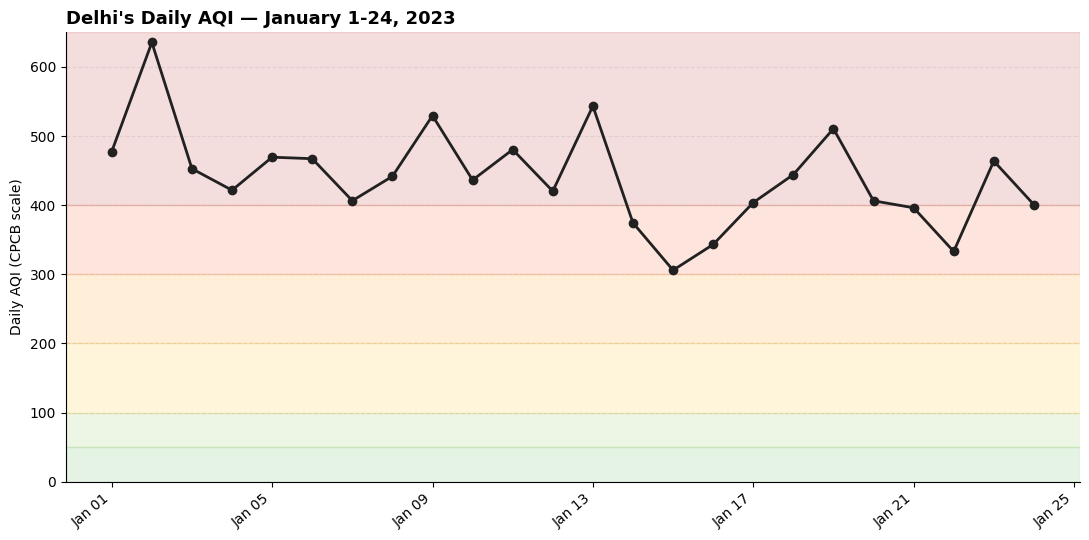

In [8]:
CAT_COLORS = {'Good':'#4CAF50','Satisfactory':'#8BC34A','Moderate':'#FFC107',
              'Poor':'#FF9800','Very Poor':'#F4511E','Severe':'#B71C1C'}
BANDS = [(0,50,'Good'),(50,100,'Satisfactory'),(100,200,'Moderate'),
         (200,300,'Poor'),(300,400,'Very Poor'),(400,650,'Severe')]

fig, ax = plt.subplots(figsize=(11,5.5))
for lo,hi,name in BANDS:
    ax.axhspan(lo, hi, color=CAT_COLORS[name], alpha=0.15, zorder=0)
ax.plot(pd.to_datetime(daily['day']), daily['AQI'], color='#212121', marker='o', linewidth=2, zorder=3)
ax.set_ylim(0,650)
ax.set_ylabel('Daily AQI (CPCB scale)')
ax.set_title("Delhi's Daily AQI — January 1-24, 2023", fontsize=13, fontweight='bold', loc='left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


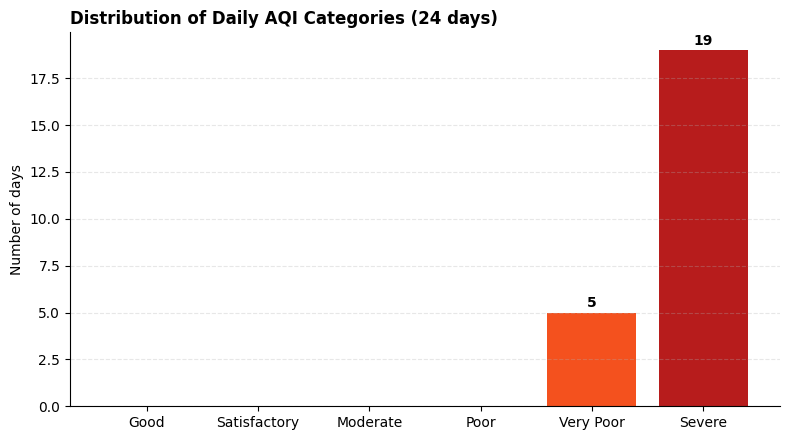

In [9]:
order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
counts = daily['category'].value_counts().reindex(order).fillna(0)

fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.bar(counts.index, counts.values, color=[CAT_COLORS[c] for c in counts.index])
for b,v in zip(bars, counts.values):
    if v>0: ax.text(b.get_x()+b.get_width()/2, v+0.3, int(v), ha='center', fontweight='bold')
ax.set_ylabel('Number of days')
ax.set_title('Distribution of Daily AQI Categories (24 days)', fontsize=12, fontweight='bold', loc='left')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


**Finding (RQ1):** Every single day in the sample was rated **Very Poor or Severe** — 19/24 days (79%) Severe,
5/24 (21%) Very Poor. Mean daily AQI = **440**. All 24 days breached both the Indian NAAQS and WHO PM2.5 guidelines.

## 5. RQ2 — Pollutant Dominance & Correlation

In [10]:
print("Dominant pollutant frequency (days):")
print(daily['dominant_pollutant'].value_counts())
print()
print("As % of days:")
print((daily['dominant_pollutant'].value_counts(normalize=True)*100).round(1))


Dominant pollutant frequency (days):
dominant_pollutant
pm2_5    21
pm10      3
Name: count, dtype: int64

As % of days:
dominant_pollutant
pm2_5    87.5
pm10     12.5
Name: proportion, dtype: float64


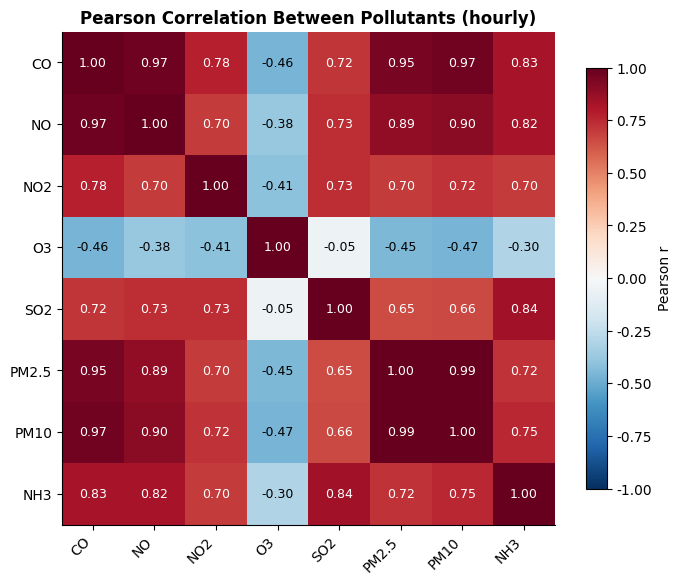

,co,no,no2,o3,so2,pm2_5,pm10,nh3
co,1.00,0.97,0.78,-0.46,0.72,0.95,0.97,0.83
no,0.97,1.00,0.70,-0.38,0.73,0.89,0.90,0.82
no2,0.78,0.70,1.00,-0.41,0.73,0.70,0.72,0.70
o3,-0.46,-0.38,-0.41,1.00,-0.05,-0.45,-0.47,-0.30
so2,0.72,0.73,0.73,-0.05,1.00,0.65,0.66,0.84
pm2_5,0.95,0.89,0.70,-0.45,0.65,1.00,0.99,0.72
pm10,0.97,0.90,0.72,-0.47,0.66,0.99,1.00,0.75
nh3,0.83,0.82,0.70,-0.30,0.84,0.72,0.75,1.00


In [11]:
corr = df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']].corr()
labels = ['CO','NO','NO2','O3','SO2','PM2.5','PM10','NH3']

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.iloc[i,j]
        ax.text(j,i, f'{v:.2f}', ha='center', va='center', color='white' if abs(v)>0.6 else 'black', fontsize=9)
ax.set_title('Pearson Correlation Between Pollutants (hourly)', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.show()

corr.round(2)


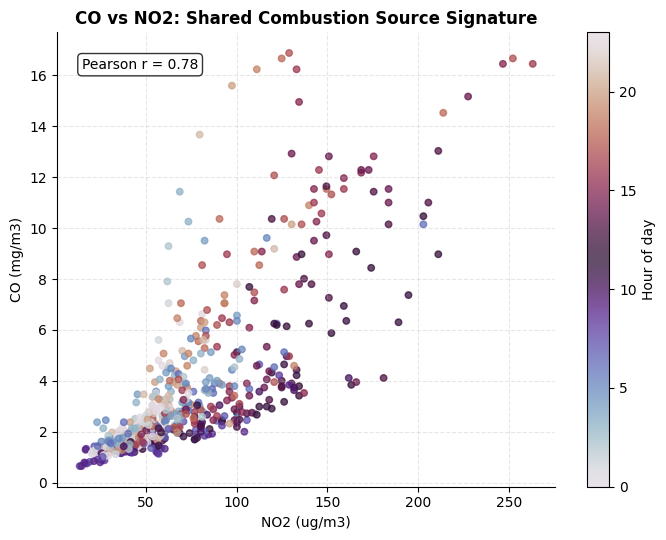

In [12]:
fig, ax = plt.subplots(figsize=(7,5.5))
sc = ax.scatter(df['no2'], df['co']/1000, c=df['hour'], cmap='twilight', s=22, alpha=0.75)
ax.set_xlabel('NO2 (ug/m3)'); ax.set_ylabel('CO (mg/m3)')
ax.set_title('CO vs NO2: Shared Combustion Source Signature', fontsize=12, fontweight='bold')
r = df['no2'].corr(df['co'])
ax.text(0.05,0.92, f'Pearson r = {r:.2f}', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
cbar = fig.colorbar(sc, ax=ax); cbar.set_label('Hour of day')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


**Finding (RQ2):** PM2.5 is the dominant (AQI-determining) pollutant on **87.5%** of days, PM10 on the
remaining 12.5% — no gaseous pollutant ever drives the AQI. Combustion-linked pollutants (CO, NO, NO2, PM2.5,
PM10, NH3) are strongly positively inter-correlated (r = 0.70–0.99), consistent with shared sources (traffic,
biomass burning). Ozone is negatively correlated with all of these (r = -0.30 to -0.47), consistent with its
secondary photochemical formation and titration by fresh NO.

## 6. RQ3 — Diurnal (Hour-of-Day) Patterns

In [13]:
hourly_avg = df.groupby('hour')[['pm2_5','pm10','no2','co','o3','so2','nh3']].mean()
hourly_std = df.groupby('hour')[['pm2_5','pm10']].std()
hourly_avg.round(1)


,pm2_5,pm10,no2,co,o3,so2,nh3
hour,,,,,,,
0,284.6,314.6,43.1,2207.4,19.6,26.9,8.8
1,295.6,328.8,47.4,2405.5,14.8,31.8,11.2
2,336.3,382.4,57.0,3114.2,6.2,40.1,15.4
3,362.6,416.6,63.3,3719.5,3.2,46.1,16.9
4,334.5,386.7,65.4,3448.6,11.3,54.4,17.1
5,332.6,388.5,67.0,3445.2,22.3,61.9,19.6
6,332.9,388.7,74.6,3339.5,40.5,70.3,20.0
7,216.3,245.3,55.8,1833.9,86.6,84.5,10.1
8,194.3,218.9,50.1,1554.6,105.8,81.0,9.0


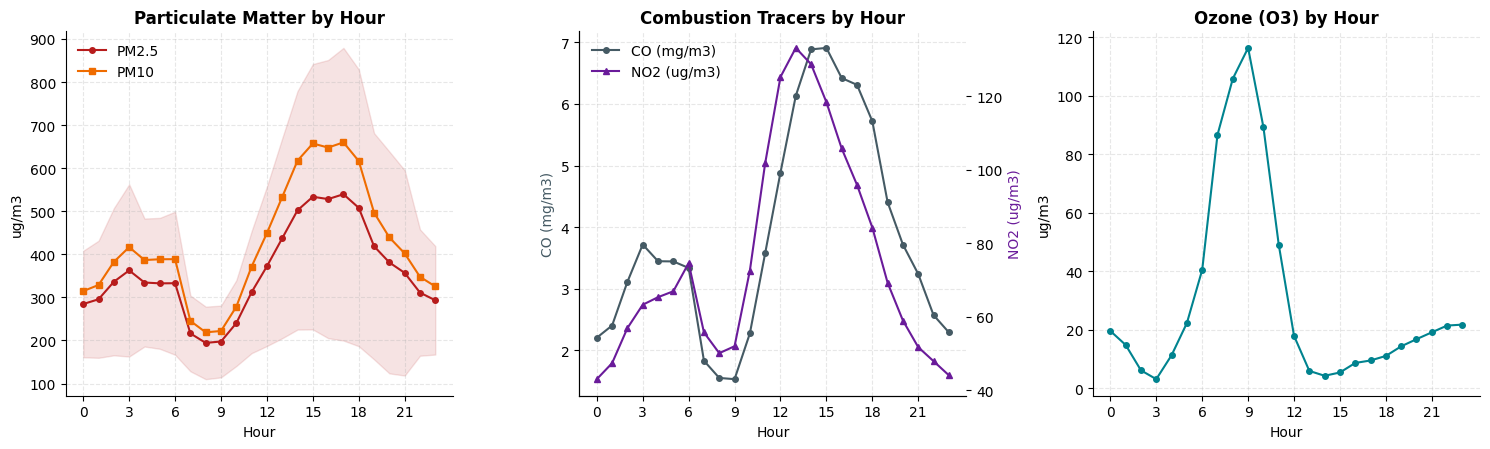

PM2.5 minimum hour: 8 -> 194.3
PM2.5 maximum hour: 17 -> 539.5
O3 maximum hour: 9 -> 116.3


In [14]:
fig, axes = plt.subplots(1,3, figsize=(15,4.6))

ax = axes[0]
ax.plot(hourly_avg.index, hourly_avg['pm2_5'], color='#B71C1C', marker='o', markersize=4, label='PM2.5')
ax.fill_between(hourly_avg.index, hourly_avg['pm2_5']-hourly_std['pm2_5'], hourly_avg['pm2_5']+hourly_std['pm2_5'],
                color='#B71C1C', alpha=0.12)
ax.plot(hourly_avg.index, hourly_avg['pm10'], color='#EF6C00', marker='s', markersize=4, label='PM10')
ax.set_title('Particulate Matter by Hour', fontweight='bold'); ax.set_xlabel('Hour'); ax.set_ylabel('ug/m3')
ax.legend(frameon=False); ax.set_xticks(range(0,24,3)); ax.grid(alpha=0.3, linestyle='--')

ax = axes[1]
ax2 = ax.twinx()
l1, = ax.plot(hourly_avg.index, hourly_avg['co']/1000, color='#455A64', marker='o', markersize=4, label='CO (mg/m3)')
l2, = ax2.plot(hourly_avg.index, hourly_avg['no2'], color='#6A1B9A', marker='^', markersize=4, label='NO2 (ug/m3)')
ax.set_title('Combustion Tracers by Hour', fontweight='bold'); ax.set_xlabel('Hour')
ax.set_ylabel('CO (mg/m3)', color='#455A64'); ax2.set_ylabel('NO2 (ug/m3)', color='#6A1B9A')
ax.set_xticks(range(0,24,3)); ax.legend(handles=[l1,l2], frameon=False, loc='upper left')
ax.grid(alpha=0.3, linestyle='--')

ax = axes[2]
ax.plot(hourly_avg.index, hourly_avg['o3'], color='#00838F', marker='o', markersize=4)
ax.set_title('Ozone (O3) by Hour', fontweight='bold'); ax.set_xlabel('Hour'); ax.set_ylabel('ug/m3')
ax.set_xticks(range(0,24,3)); ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("PM2.5 minimum hour:", hourly_avg['pm2_5'].idxmin(), "->", round(hourly_avg['pm2_5'].min(),1))
print("PM2.5 maximum hour:", hourly_avg['pm2_5'].idxmax(), "->", round(hourly_avg['pm2_5'].max(),1))
print("O3 maximum hour:", hourly_avg['o3'].idxmax(), "->", round(hourly_avg['o3'].max(),1))


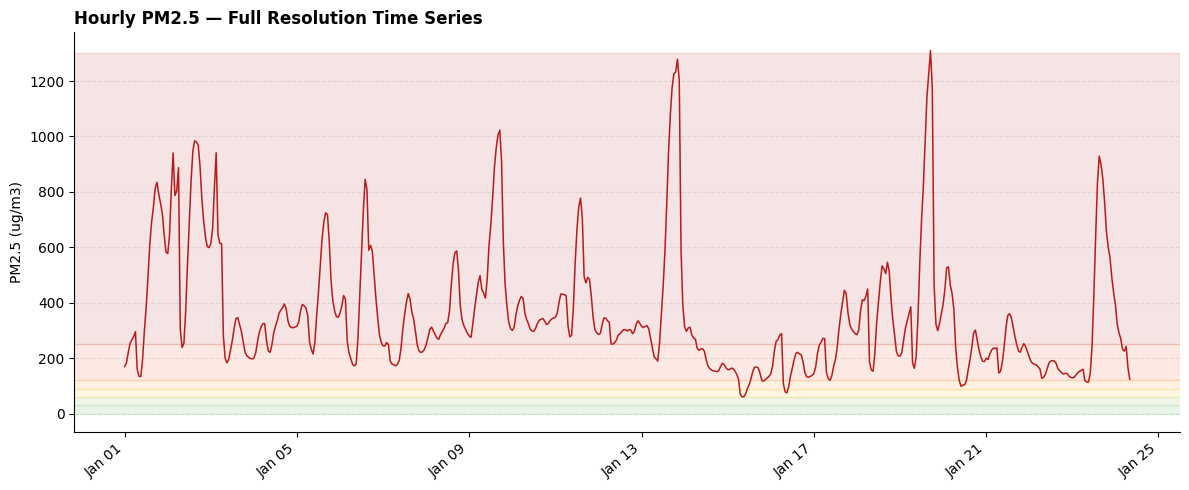

In [15]:
fig, ax = plt.subplots(figsize=(12,5))
for lo,hi,name in [(0,30,'Good'),(30,60,'Satisfactory'),(60,90,'Moderate'),
                    (90,120,'Poor'),(120,250,'Very Poor'),(250,1300,'Severe')]:
    ax.axhspan(lo, hi, color=CAT_COLORS[name], alpha=0.12, zorder=0)
ax.plot(df['date'], df['pm2_5'], color='#B71C1C', linewidth=1.1)
ax.set_ylabel('PM2.5 (ug/m3)')
ax.set_title('Hourly PM2.5 — Full Resolution Time Series', fontsize=12, fontweight='bold', loc='left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


**Finding (RQ3):** PM2.5/PM10 are lowest around **07:00-09:00** and build to a peak around **15:00-17:00**
(~2.7x swing). CO and NO2 are elevated overnight, dip sharply near 07:00-09:00, then climb to a midday/afternoon
peak. O3 shows the inverse (near-zero overnight, peaking ~09:00-10:00) — the classic signature of a
photochemically-formed secondary pollutant.

## 7. RQ4 — Geographic & Meteorological Context

*(Interpretation, not directly testable with this dataset alone — no wind/temperature/boundary-layer variables were provided.)*

- **Temperature inversion:** winter radiative cooling creates a stable layer that traps emissions near the ground overnight — consistent with elevated overnight CO/NO2.
- **Mixing-layer cycle:** morning boundary-layer expansion dilutes near-surface pollutants (the 07:00-09:00 dip); afternoon re-shallowing plus continued emissions drives the 15:00-18:00 peak.
- **Topography & regional transport:** the Indo-Gangetic Plain restricts dispersion; calm winter winds and Punjab/Haryana crop-residue burning smoke compound the effect.
- **Limitation:** the observed single broad afternoon peak (rather than a classic two-peak rush-hour pattern) may partly reflect this data source's characteristics; pairing with meteorological data would let this be tested directly rather than inferred.


## 8. Summary Table & Export

In [16]:
summary = daily[['day','pm2_5','pm10','AQI','category','dominant_pollutant']].copy()
summary.columns = ['Date','Mean PM2.5','Mean PM10','AQI','Category','Dominant Pollutant']
summary['Mean PM2.5'] = summary['Mean PM2.5'].round(1)
summary['Mean PM10'] = summary['Mean PM10'].round(1)
summary


,Date,Mean PM2.5,Mean PM10,AQI,Category,Dominant Pollutant
0,2023-01-01,443.9,535.0,477.6,Severe,pm2_5
1,2023-01-02,698.1,830.1,635.4,Severe,pm10
2,2023-01-03,381.8,434.3,452.7,Severe,pm2_5
3,2023-01-04,304.0,350.5,421.6,Severe,pm2_5
4,2023-01-05,423.6,496.8,469.4,Severe,pm2_5
5,2023-01-06,418.1,494.5,467.2,Severe,pm2_5
6,2023-01-07,265.9,294.6,406.4,Severe,pm2_5
7,2023-01-08,354.2,396.3,441.7,Severe,pm2_5
8,2023-01-09,557.8,650.2,529.5,Severe,pm10
9,2023-01-10,340.8,376.4,436.3,Severe,pm2_5


In [17]:
# Export processed data for downstream use / submission
daily.to_csv('daily_aqi_results.csv', index=False)
df.to_csv('hourly_aqi_results.csv', index=False)
print("Saved: daily_aqi_results.csv, hourly_aqi_results.csv")


Saved: daily_aqi_results.csv, hourly_aqi_results.csv


## 9. Conclusions & Recommendations

1. **Every day in the 24-day sample was Very Poor or Severe** (mean AQI 440) — a sustained winter pollution crisis, not isolated spikes.
2. **PM2.5 is the overwhelming driver** of the AQI (87.5% of days) — control strategies should prioritize particulate sources (construction dust, vehicle exhaust, biomass burning) over any single gaseous pollutant.
3. **Combustion pollutants move together** (r up to 0.99), pointing to shared sources — coordinated traffic and biomass-burning interventions would address multiple pollutants simultaneously.
4. **Target interventions to the 12:00-18:00 build-up window and the 00:00-07:00 inversion window**, when the data show pollution is worst.
5. **Extend monitoring**: adding meteorological covariates (wind, boundary-layer height) and collecting a full year of data would allow direct testing of the seasonal/meteorological explanations offered here, and enable genuine season-over-season comparison.

---
*Notebook prepared as the "project" (code) deliverable accompanying the written analysis report for ShadowFox Intermediate Task 1.*
